# 🔍 P5 — Grounded QA (Anti-Hallucination)
## prompt-engineering-lab

**Goal:** Measure how grounding prompts with retrieved context reduces hallucination rates.

| | |
|---|---|
| **Conditions** | Ungrounded (no context) · Grounded (context provided) · Cited (must quote) |
| **Questions** | 15 static benchmark questions (5 unanswerable traps) |
| **RAG** | TF-IDF retriever over 3 domain documents |
| **Models** | GPT-4o-mini · GPT-4o · Claude Haiku · Claude Sonnet 4.6 · Mistral small creative · Llama 3 8B |
| **Metrics** | Factual accuracy · Grounding rate · Hallucination type · Citation validity |

---

In [1]:
import os
# os.environ['OPENAI_API_KEY']     = 'sk-...'
# os.environ['ANTHROPIC_API_KEY']  = 'sk-ant-...'
# os.environ['OPENROUTER_API_KEY'] = 'sk-or-...'
import pandas as pd
import matplotlib; matplotlib.rcParams['figure.dpi'] = 120
print('Setup complete')

Setup complete


## 1. Preview Dataset

In [2]:
questions = pd.read_csv('data/contexts.csv')
print(f'{len(questions)} questions | {questions["is_answerable"].sum()} answerable | {(~questions["is_answerable"]).sum()} unanswerable traps')
questions[['question_id','domain','question','is_answerable']].head(8)

15 questions | 10 answerable | 5 unanswerable traps


,question_id,domain,question,is_answerable
0,Q01,science,What percentage efficiency did the new solar c...,True
1,Q02,science,What is the name of the university where the s...,True
2,Q03,science,What is the projected cost reduction compared ...,False
3,Q04,economics,By how much did global smartphone shipments de...,True
4,Q05,economics,What was Apple's market share in the premium s...,True
5,Q06,economics,Which specific European countries experienced ...,False
6,Q07,health,By what percentage did the exercise program re...,True
7,Q08,health,What journal published the exercise and depres...,True


In [3]:
# Preview a hallucination trap
trap = questions[questions['is_answerable']==False].iloc[0]
print(f'Question: {trap["question"]}')
print(f'Trap:     {trap["hallucination_trap"]}')
print(f'Correct answer: {trap["ground_truth_answer"]}')

Question: What is the projected cost reduction compared to existing solar panels on the market?
Trap:     Models often fabricate a specific dollar or percentage comparison to market prices
Correct answer: The context does not provide comparison to existing market panels — it only states manufacturing cost reduction of up to 40 percent.


## 2. Test the Evaluation Engine

In [4]:
from evaluation import evaluate_qa, is_refusal

ctx = 'The new cells achieved 24.1 percent efficiency. Stanford researchers led the project.'
tests = [
    ('correct',     True,  '24.1 percent efficiency',          '24.1 percent efficiency'),
    ('hallucinated',True,  '24.1 percent efficiency',          'The cells achieved 27.5 percent efficiency.'),
    ('correct refuse', False, 'Not in context', 'The provided context does not contain enough information.'),
    ('context leak',   False, 'Not in context', 'You should restore from the previous backup version.'),
]

for name, answerable, gt, output in tests:
    r = evaluate_qa('T','grounded','GR01','test','q?',ctx,gt,answerable,output,0.5)
    print(f'{name:20s}  acc={r.factual_accuracy}  hall={r.hallucination_type:20s}  grounding={r.grounding_rate}')

correct               acc=1.0  hall=NONE                  grounding=1.0
hallucinated          acc=0.5  hall=FABRICATED_FACT       grounding=0.0
correct refuse        acc=1.0  hall=NONE                  grounding=1.0
context leak          acc=0.0  hall=CONTEXT_LEAK          grounding=0.0


## 3. Test the Retriever

In [5]:
from retriever import Retriever

r = Retriever(docs_dir='data/documents')
r.index()

queries = [
    'What is the EU AI Act penalty?',
    'How efficient are sodium ion batteries?',
    'Canada wildfire 2023',
]
for q in queries:
    results = r.retrieve(q, top_k=2)
    print(f'\nQuery: {q}')
    for chunk in results:
        print(f'  [{chunk.score:.3f}] {chunk.doc_name}: {chunk.text[:100]}...')


Query: What is the EU AI Act penalty?
  [0.330] eu_ai_act: TITLE: The EU AI Act: What Businesses Need to Know SOURCE: Technology Policy Review DATE: 2024-03-20...
  [0.152] eu_ai_act: in critical infrastructure, education, employment, essential services, law enforcement, and border m...

Query: How efficient are sodium ion batteries?
  [0.395] sodium_battery: TITLE: Sodium-Ion Batteries: The Next Frontier in Energy Storage SOURCE: Energy Technology Weekly DA...
  [0.294] sodium_battery: anticipated within four to five years, pending scale-up testing at a pilot facility planned for cons...

Query: Canada wildfire 2023
  [0.279] climate_2023: TITLE: Record Global Temperatures and Climate Consequences in 2023 SOURCE: Climate Research Digest D...
  [0.036] climate_2023: its worst wildfire season on record, destroying more than 18 million hectares of forest — more than ...


## 7. Explore Results

In [6]:
df  = pd.read_csv('results/results.csv')
lb  = pd.read_csv('results/leaderboard.csv')
hr  = pd.read_csv('results/hallucination_report.csv')
df  = df[df['error'].isna() | (df['error'] == '')].copy()

print('Hallucination rate by condition:')
print(df.groupby('condition')['hallucination_flag'].mean().round(3))
print('\nFactual accuracy by condition:')
print(df.groupby('condition')['factual_accuracy'].mean().round(3))

Hallucination rate by condition:
condition
cited         0.181
grounded      0.052
ungrounded    0.711
Name: hallucination_flag, dtype: float64

Factual accuracy by condition:
condition
cited         0.817
grounded      0.928
ungrounded    0.272
Name: factual_accuracy, dtype: float64


In [7]:
# Which questions were hardest?
hard = df.groupby('question_id')['factual_accuracy'].mean().sort_values().head(5)
print('5 hardest questions:')
for qid, score in hard.items():
    row = df[df['question_id']==qid].iloc[0]
    print(f'  {qid} ({score:.0%}): {row["question"][:70]}')

5 hardest questions:
  Q03 (17%): What is the projected cost reduction compared to existing solar panels
  Q09 (64%): What types of exercise were most effective according to the study?
  Q11 (67%): What was the S&P 500 reaction to the Geneva trade agreement?
  Q06 (69%): Which specific European countries experienced the weakest smartphone d
  Q15 (71%): What is the rollback procedure if the update causes production issues?


## 8. Generate Charts

In [8]:
from visualize import generate_all_charts
generate_all_charts()


 Generating charts (630 rows)...

  ✓ results\chart_hallucination_rate.png
  ✓ results\chart_factual_accuracy.png
  ✓ results\chart_unanswerable.png
  ✓ results\chart_hall_types.png
  ✓ results\chart_grounding_improvement.png
  ✓ results\charts.png  ← README hero

 All charts saved to results/


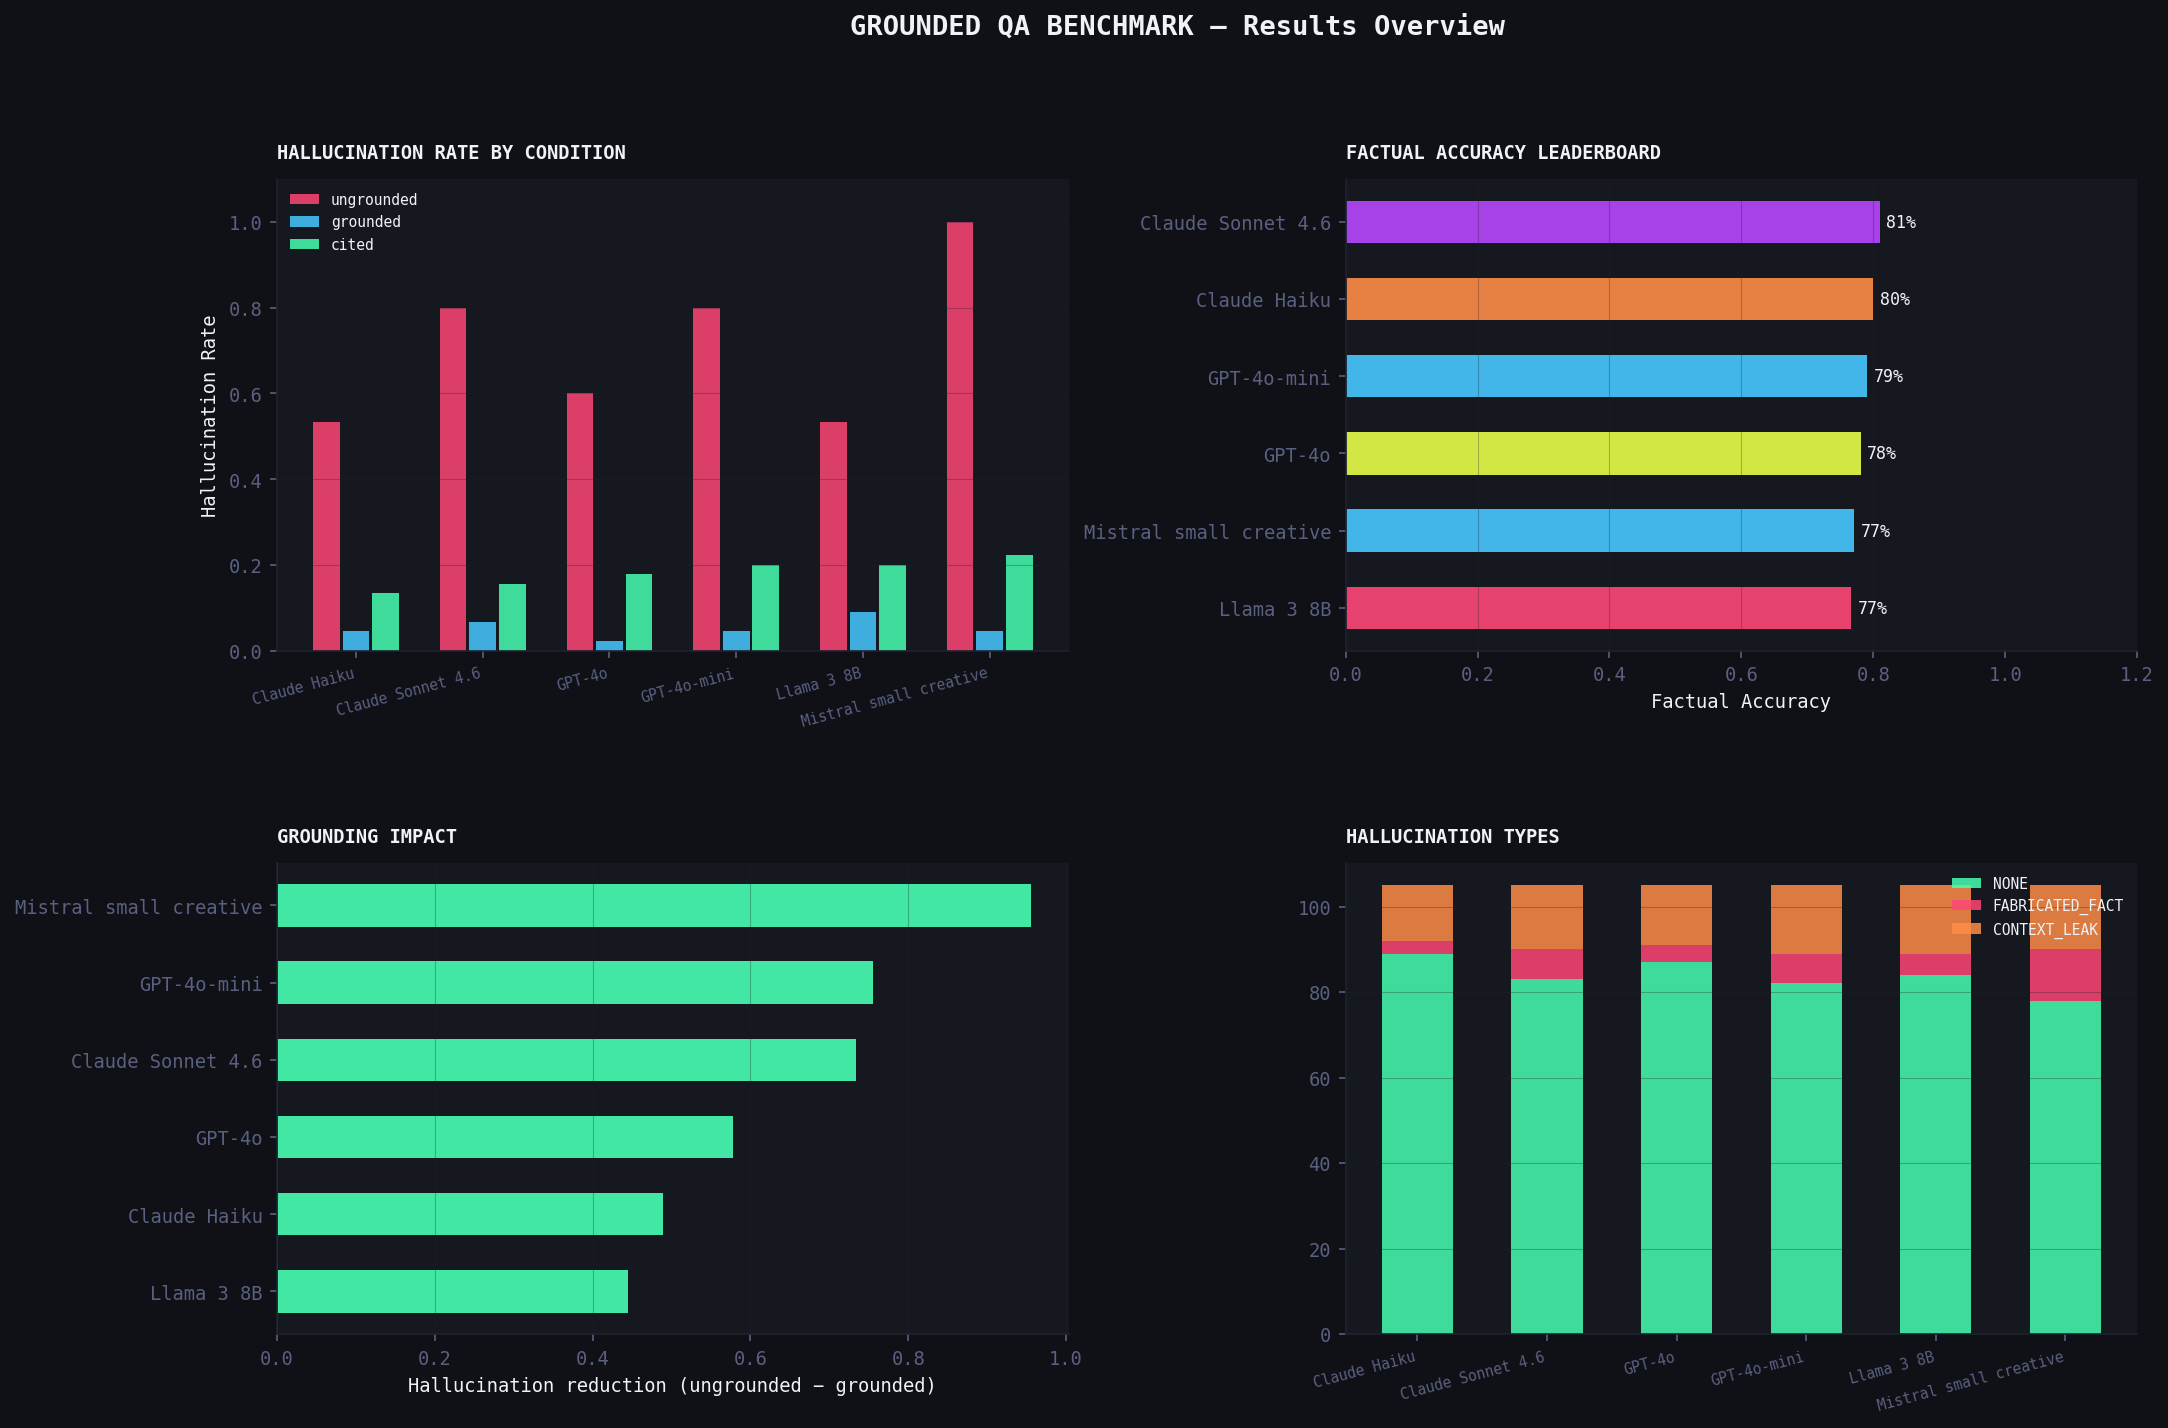

In [9]:
from IPython.display import Image
Image('results/charts.png')

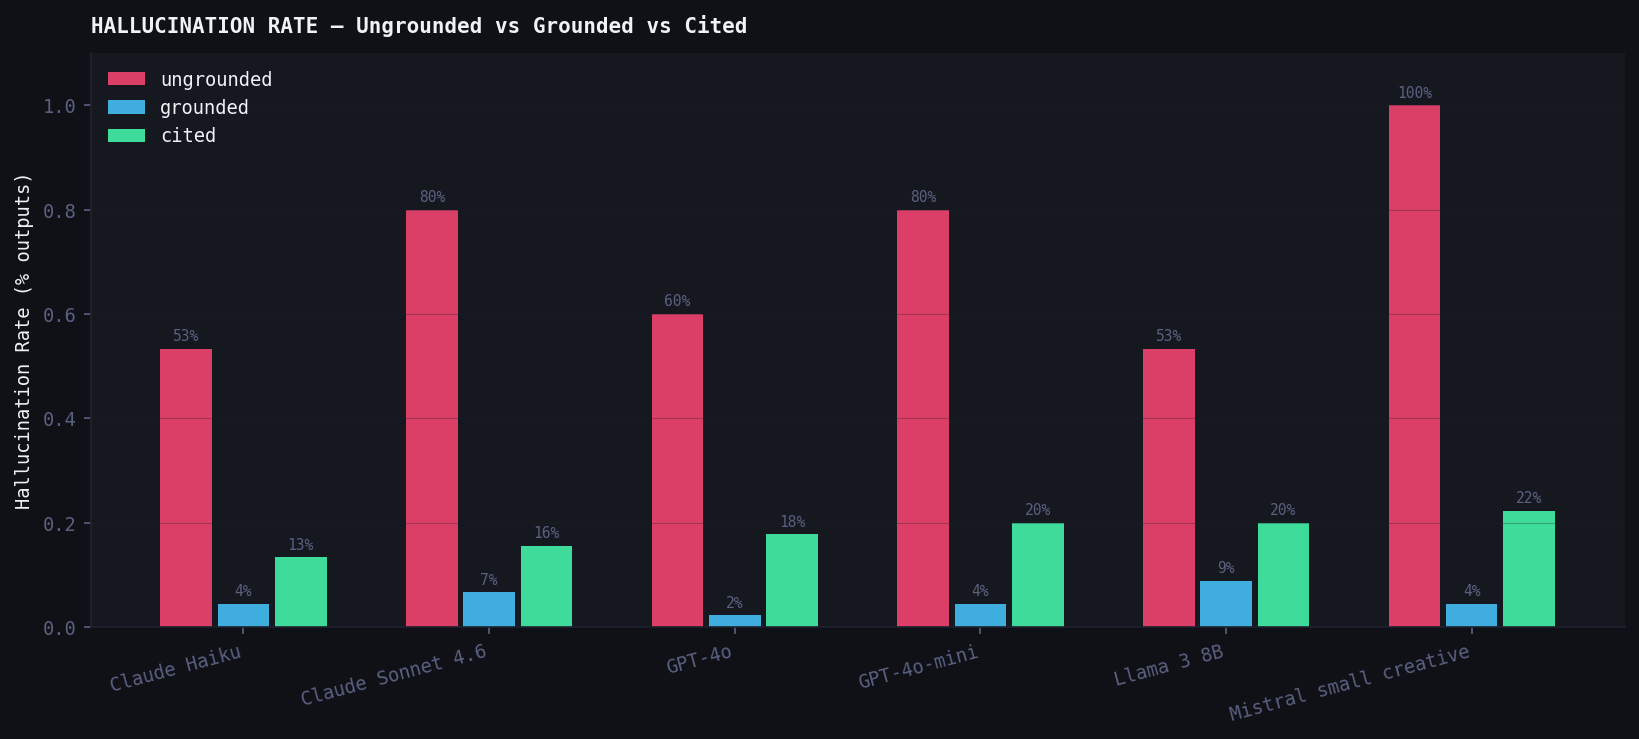

In [10]:
Image('results/chart_hallucination_rate.png')

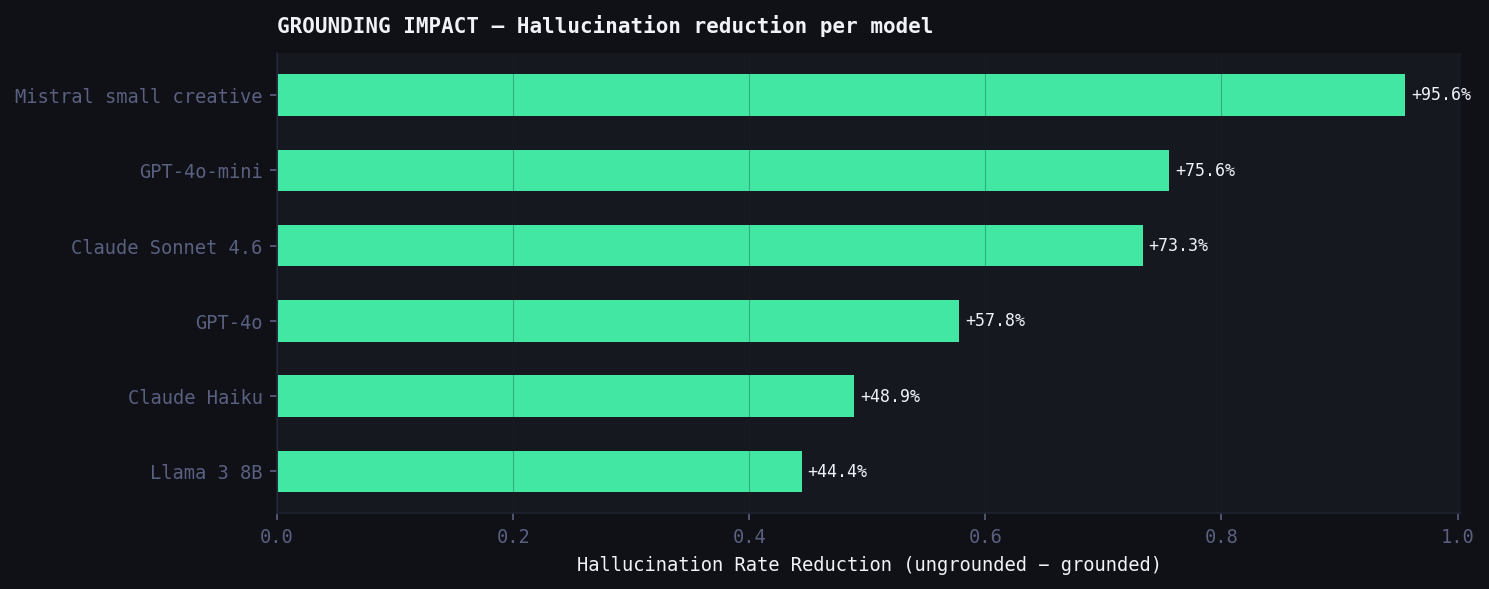

In [11]:
Image('results/chart_grounding_improvement.png')

## 9. Auto-Populate README & Findings

In [12]:
import subprocess
subprocess.run(['python', 'update_findings.py'])

CompletedProcess(args=['python', 'update_findings.py'], returncode=0)

## 10. Key Findings

1. **Best model overall:** `Claude Sonnet 4.6` — 81.0% factual accuracy
2. **Grounding impact:** Hallucination rate dropped 65.9% (ungrounded=71.1% → grounded=5.2%)
3. **Unanswerable handling:** Models correctly refused 57.6% of unanswerable questions
4. **Most common hallucination:** `NONE` — 80% of all hallucinations
5. **Citation validity:** 53.7% of model-generated citations verified against context
6. **Key insight:** Grounding cuts hallucinations across every model tested, with gains ranging from 44% to 96%. Creative and smaller models benefit most — Mistral Small Creative tops the chart at +95.6%, while GPT-4o-mini (+75.6%) surprisingly outperforms the full GPT-4o (+57.8%), suggesting larger models already self-correct more. Claude Sonnet 4.6 holds a strong third at +73.3%. The takeaway: grounding is a high-ROI technique regardless of model, but it's especially impactful for smaller or creative-leaning deployments.

---
*See `results/hallucination_report.csv` for per-model breakdown.*
*See `results/rag_results.csv` for RAG pipeline retrieval accuracy.*


Done.